In [6]:
#All the imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from scipy.stats import kurtosis
from scipy.ndimage import maximum_filter, label
import multiprocessing as mp
import os
from concurrent.futures import ProcessPoolExecutor

In [7]:
#Function Definitions
def partial_x_2d(f,dx):
    """Compute ∂f/∂x using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dx = np.zeros_like(f)
    
    # Central difference in x-direction (axis=0)
    df_dx[1:Nx-1, :] = (f[2:Nx, :] - f[0:Nx-2, :]) / (2 * dx)
    
    # Periodic boundaries (x-direction)
    df_dx[0, :] = (f[1, :] - f[-1, :]) / (2 * dx)
    df_dx[-1, :] = (f[0, :] - f[-2, :]) / (2 * dx)
    
    return df_dx

def partial_y_2d(f,dy):
    """Compute ∂f/∂y using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dy = np.zeros_like(f)
    
    # Central difference in y-direction (axis=1)
    df_dy[:, 1:Ny-1] = (f[:, 2:Ny] - f[:, 0:Ny-2]) / (2 * dy)
    
    # Periodic boundaries (y-direction)
    df_dy[:, 0] = (f[:, 1] - f[:, -1]) / (2 * dy)
    df_dy[:, -1] = (f[:, 0] - f[:, -2]) / (2 * dy)
    
    return df_dy

def partial_x_fft(f, dx):
    """
    Calculate ∂f/∂x using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dx (float): Grid spacing in the x-direction.

    Returns:
        df_dx (2D np.array): Partial derivative ∂f/∂x.
    """
    nx, ny = f.shape
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi  # Wavenumbers in x
    kx = kx[:, np.newaxis]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dx_hat = 1j * kx * f_hat
    df_dx = np.fft.ifft2(df_dx_hat).real

    return np.array(df_dx)

def partial_y_fft(f, dy):
    """
    Calculate ∂f/∂y using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dy (float): Grid spacing in the y-direction.

    Returns:
        df_dy (2D np.array): Partial derivative ∂f/∂y.
    """
    nx, ny = f.shape
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi  # Wavenumbers in y
    ky = ky[np.newaxis, :]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dy_hat = 1j * ky * f_hat
    df_dy = np.fft.ifft2(df_dy_hat).real

    return df_dy

def index_of_just_smaller(arr, value):
    arr = np.asarray(arr)
    mask = arr < value
    if not np.any(mask):
        return None  # No smaller value exists
    return np.argmax(np.where(mask, arr, -np.inf))

In [3]:
# List of simulation directories
sim_dirs = [
    '/DATA/DEVESH/ExtremeBetaSimulations/0.0625/'
]

dx = 0.0625
dy = 0.0625
eta = 2.5e-4

In [10]:
# Prevent FFT oversubscription
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

def compute_kdiss_for_time(args):

    t, base_path = args

    # print(f"Processing time step: {t}", flush=True)

    File_Bx = f"{base_path}/Bx_ApJ_t{t}.h5"
    File_By = f"{base_path}/By_ApJ_t{t}.h5"
    File_Bz = f"{base_path}/Bz_ApJ_t{t}.h5"

    with h5py.File(File_Bx, 'r') as fBx, \
         h5py.File(File_By, 'r') as fBy, \
         h5py.File(File_Bz, 'r') as fBz:

        data_Bx = fBx['DS1'][:].T
        data_By = fBy['DS1'][:].T
        data_Bz = fBz['DS1'][:].T

    data_Jx =  partial_y_fft(data_Bz, dx)
    data_Jy = -partial_x_fft(data_Bz, dx)
    data_Jz =  partial_x_fft(data_By, dx) - partial_y_fft(data_Bx, dx)

    data_Jsquared = data_Jx**2 + data_Jy**2 + data_Jz**2

    kdiss = np.mean(data_Jsquared)**0.25 / np.sqrt(eta)

    return kdiss

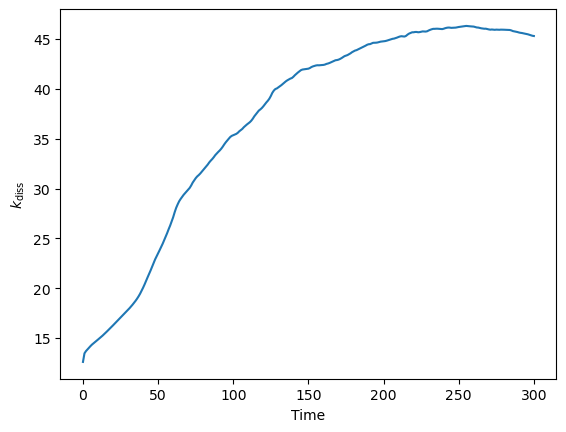

In [11]:
if __name__ == "__main__":

    base_path = "/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_0.0625/beta_e_1"

    times = list(range(0, 301))

    # Create iterable of arguments
    args_list = [(t, base_path) for t in times]

    with ProcessPoolExecutor(max_workers=128) as executor:
        kdiss_list = list(executor.map(compute_kdiss_for_time, args_list))

    kdiss_list = np.array(kdiss_list)

    plt.plot(times, kdiss_list)
    plt.xlabel("Time")
    plt.ylabel(r"$k_{\mathrm{diss}}$")
    plt.savefig("kdiss_beta0.0625.png", dpi=300)
    plt.show()

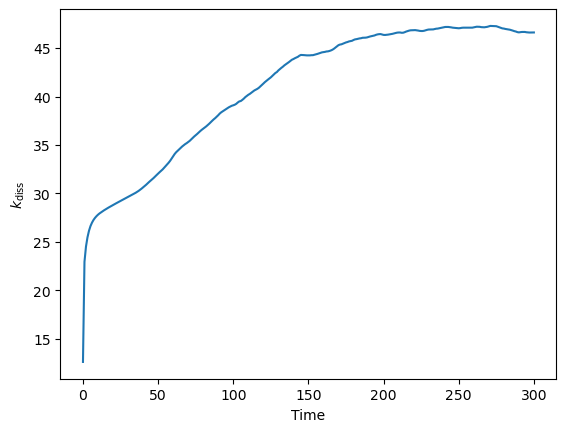

In [12]:
if __name__ == "__main__":

    base_path = "/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_1/beta_e_1"

    times = list(range(0, 301))

    # Create iterable of arguments
    args_list = [(t, base_path) for t in times]

    with ProcessPoolExecutor(max_workers=128) as executor:
        kdiss_list = list(executor.map(compute_kdiss_for_time, args_list))

    kdiss_list = np.array(kdiss_list)

    plt.plot(times, kdiss_list)
    plt.xlabel("Time")
    plt.ylabel(r"$k_{\mathrm{diss}}$")
    plt.savefig("kdiss_beta1.png", dpi=300)
    plt.show()

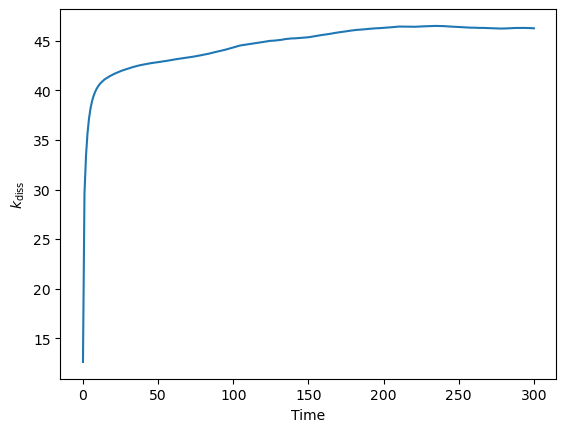

In [13]:
if __name__ == "__main__":

    base_path = "/home/UNN/w24021992/NAS/simulations_beta_scan/beta_p_16/beta_e_1"

    times = list(range(0, 301))

    # Create iterable of arguments
    args_list = [(t, base_path) for t in times]

    with ProcessPoolExecutor(max_workers=128) as executor:
        kdiss_list = list(executor.map(compute_kdiss_for_time, args_list))

    kdiss_list = np.array(kdiss_list)

    plt.plot(times, kdiss_list)
    plt.xlabel("Time")
    plt.ylabel(r"$k_{\mathrm{diss}}$")
    plt.savefig("kdiss_beta16.png", dpi=300)
    plt.show()